In [ ]:
%load_ext autoreload 
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


Importation of our class from other files 

In [ ]:
from Main_functions import Potential_extraction
from Main_functions import Generation_quad
from Main_functions import Data_exploitation
from Main_functions import SimulationParaxiale
from Main_functions import Data_exploitation_whitoutfit
from Main_functions import Data_exploitation_1982
from Extraction_data import Extracted_data
from okayama_quad import Okayama_quad
from Multipolar_decomposition import Decomposition
from Fit_functions import Fit_constants
from paraxial import Ion
import numpy as np
from aberration import Aberration



In [ ]:
Va = 20000
tension1 = {
    "va1":  0.018808 * Va,   # Tension Aperture 10.18808
    "va2": -0.018808 * Va,    # Tension Aperture 2
    "vq13": 0.0299087 * Va,    # Tension Quad 1&3
    "vq24": -0.0299087 * Va,      #tension quad 2 et 4        
    "vaAc": Va,               # Tension acceleation
}
tension1 = {
    "va1":  1 * Va,   # Tension Aperture
    "va2": -1 * Va,    # Tension Aperture 2
    "vq13": 1* Va,    # Tension Quad 1&3
    "vq24": -1 * Va,      #tension quad 2 et 4        
    "vaAc": Va,               # Tension acceleation
}
r = -200 # en V
q = 651.8 # en V
tension = {
    "va1":  r,   # Tension Aperture 10.18808
    "va2": 0,    # Tension Aperture 2
    "vq13": q,    # Tension Quad 1&3
    "vq24": -q,      #tension quad 2 et 4        
    "vaAc": Va, 
}
out_dir = "FilesTest"

In [ ]:
quad = Generation_quad(tension, out_dir)
file_path_quad = quad.reconstr()

Fichier reconstruit sauvegardé : FilesTest\quad_reconstuit.npz


5.22


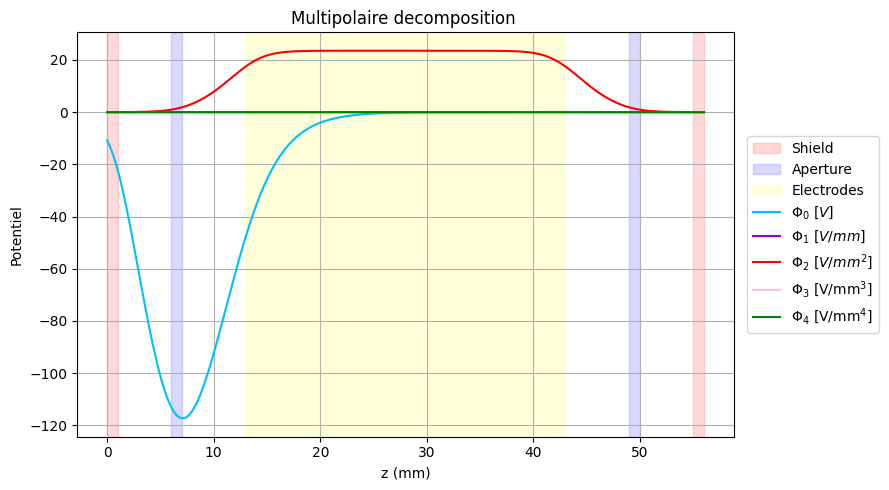

valeur theroqie de phi2 max Vq/a2 = 2000
valeur de phi2 max 23.541383044806466


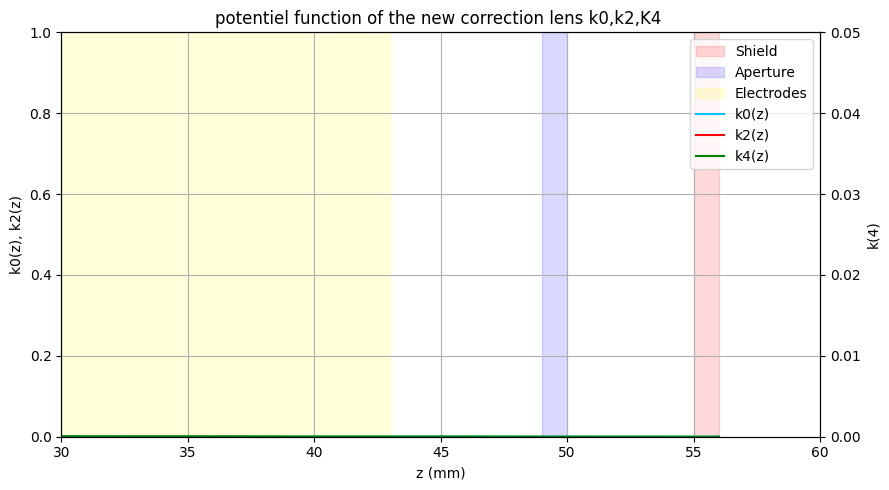

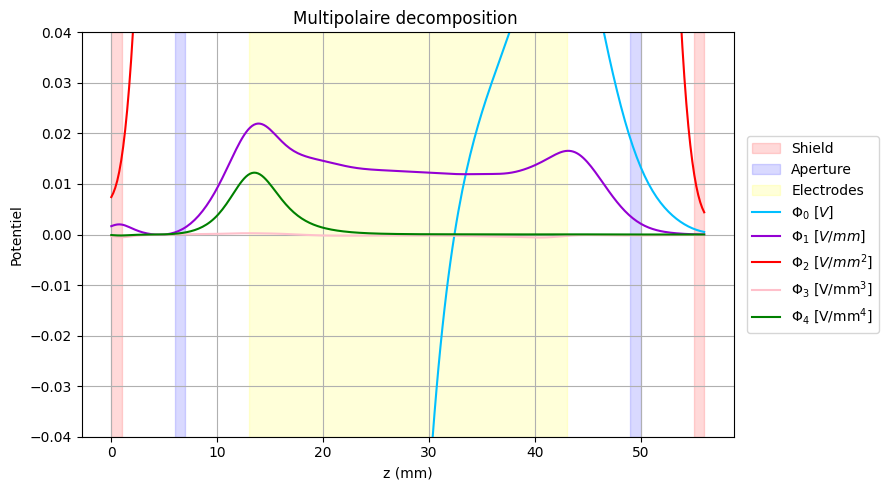

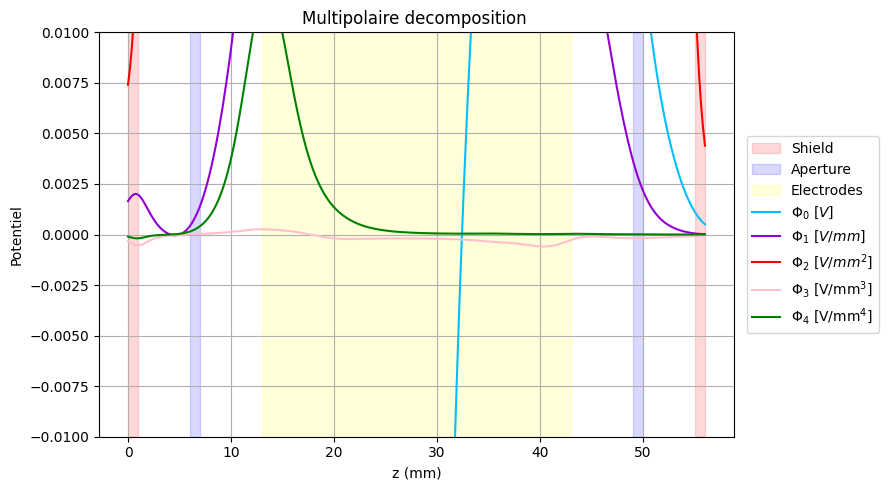

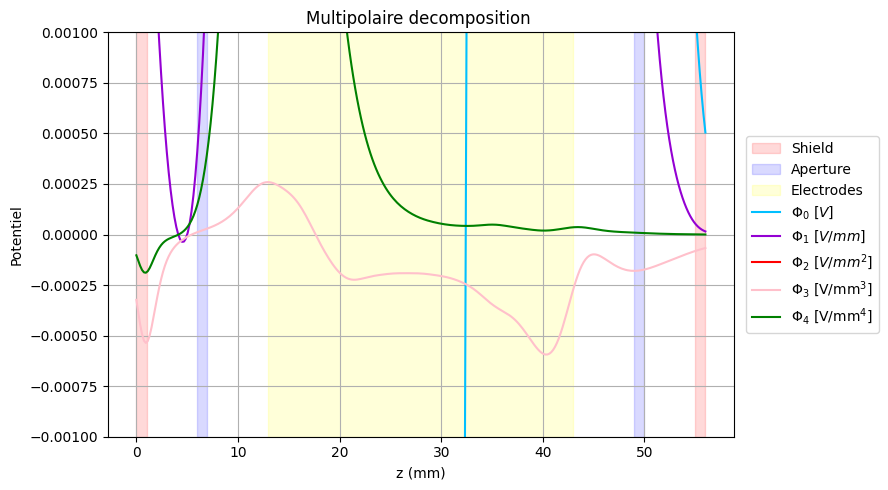

In [ ]:
extracted_data = Extracted_data(file_path_quad) 
print(extracted_data.radius_axis)
extracted_data.derivative()

fun = Data_exploitation_1982(extracted_data)
fun.decomposition_calculation()
fun.decomposition_graph()
fun.zoom_y(-0.04, 0.04)
fun.zoom_y(-0.01, 0.01)
fun.zoom_y(-0.001, 0.001)


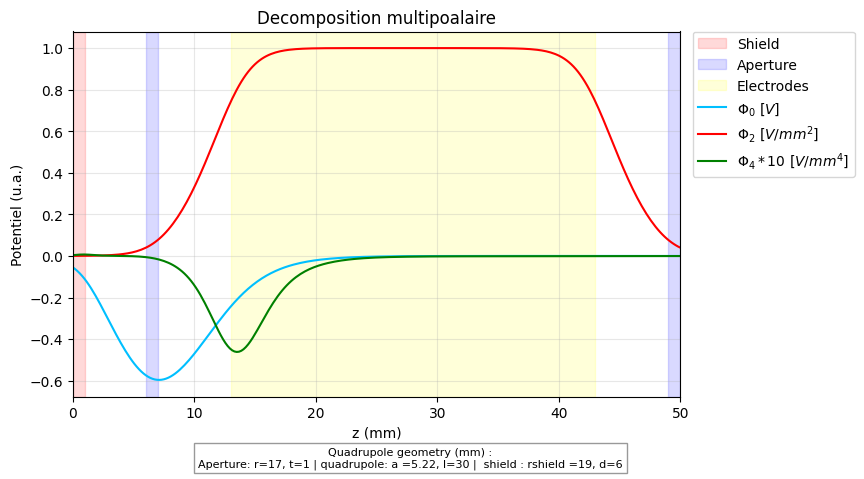

In [ ]:

fun.fit_graph()

Trajectoire Paraxiale

20000
20000


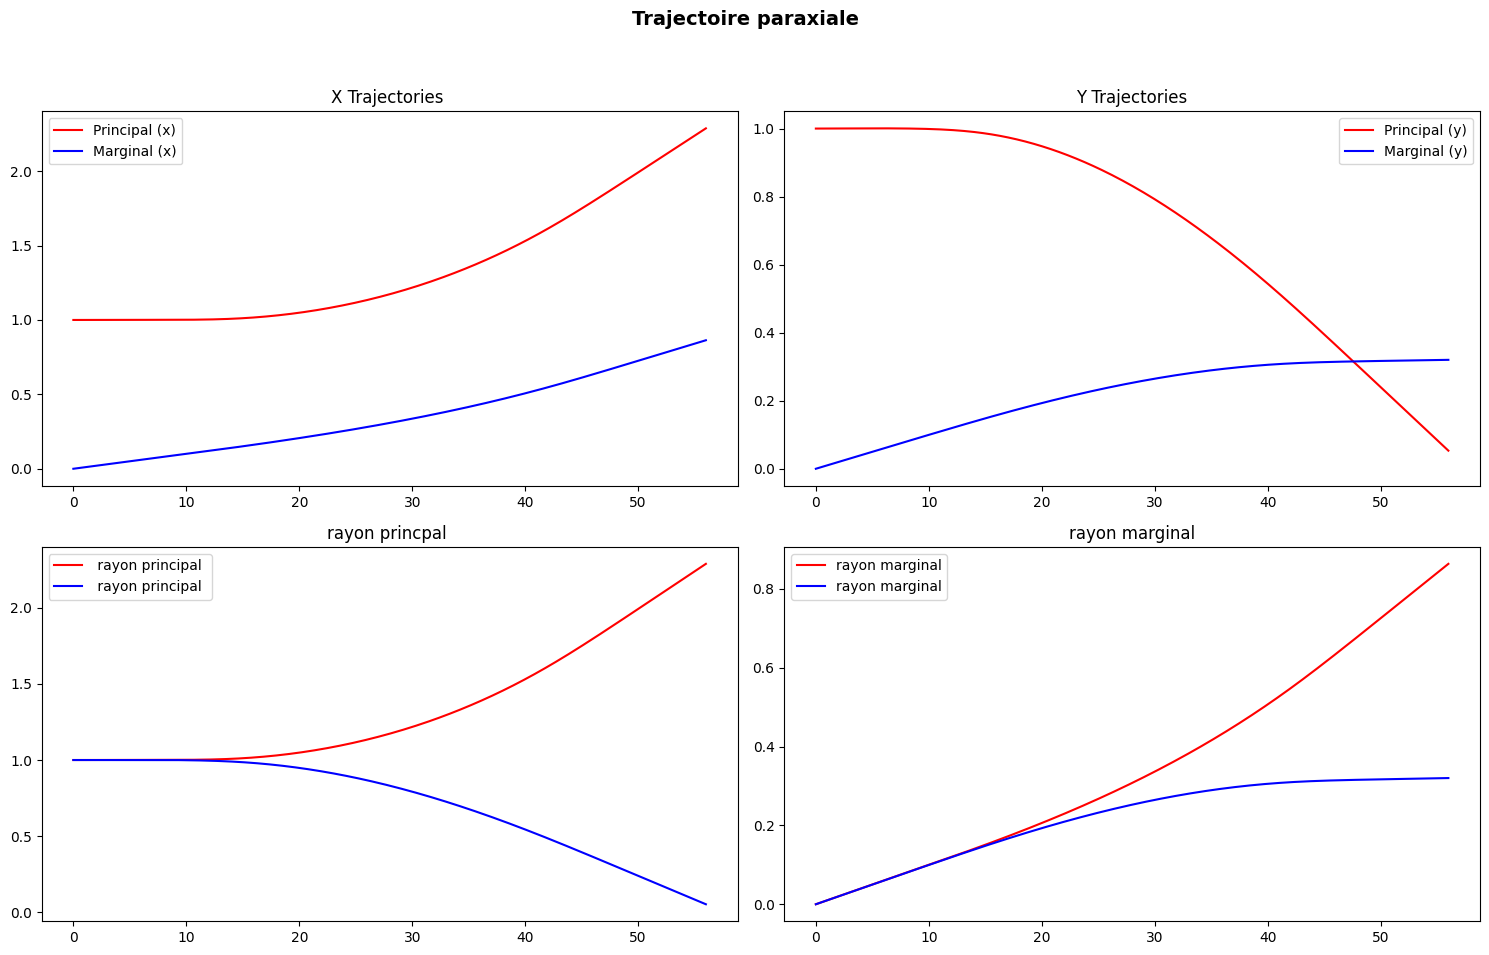

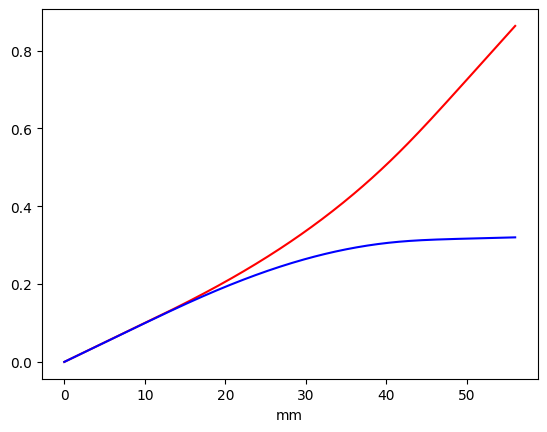

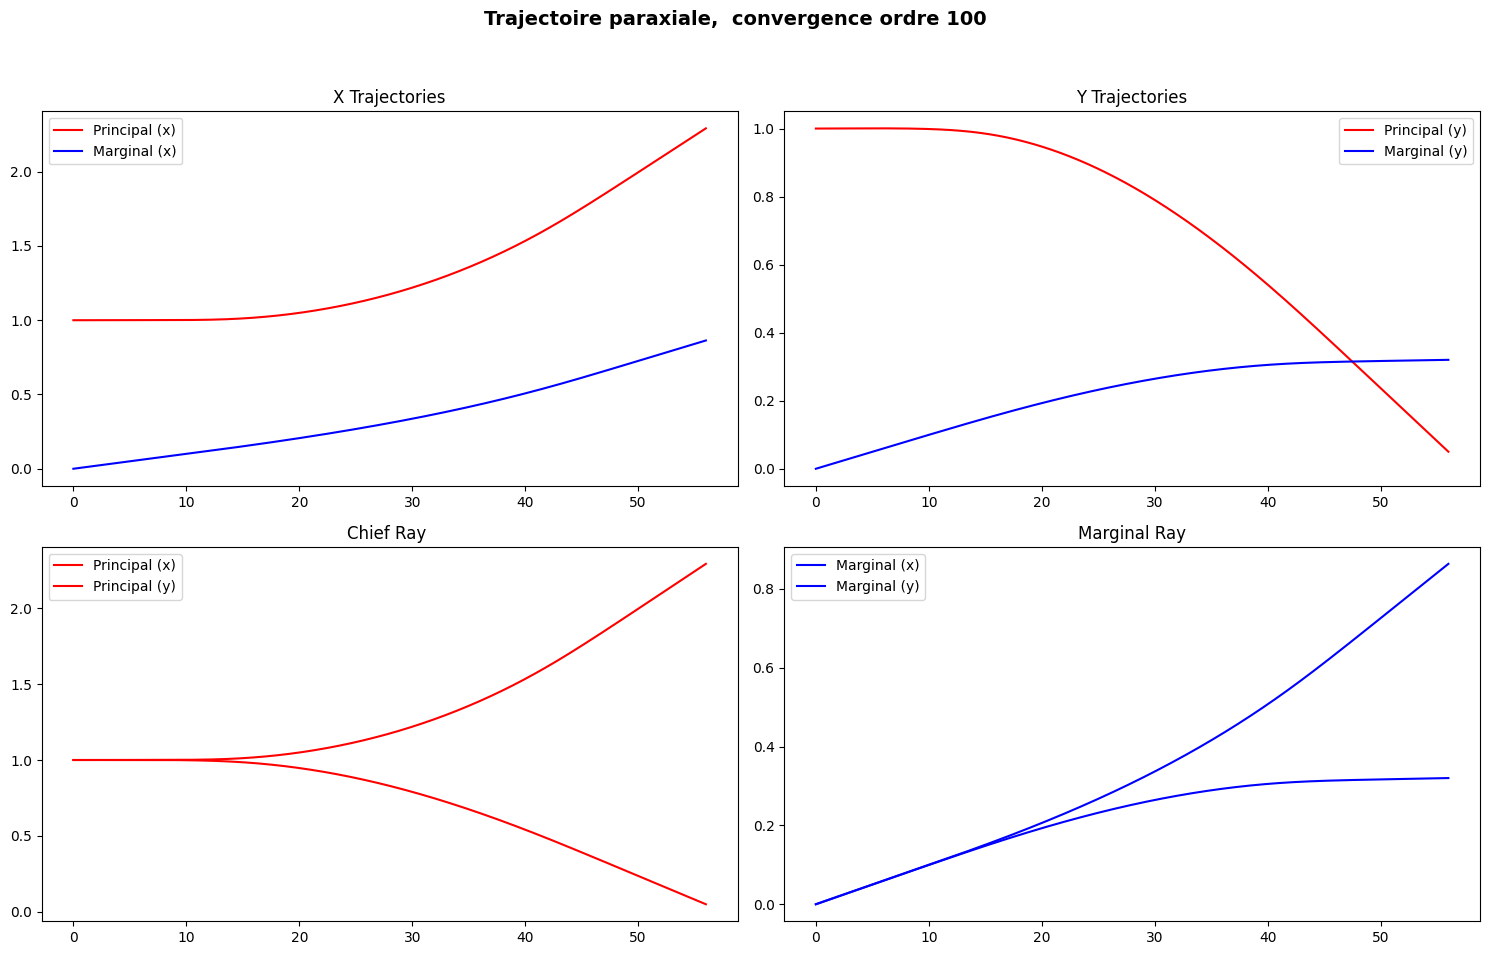

In [ ]:
n = 100
e = -1.6e-19
Decomp= Decomposition(extracted_data)
Decomp.composantes()

principal = Ion(1.6e-27, e, "principal", 0, 0.01, 0, 0.01)
marginal = Ion(1.6e-27, e, "marginal", 1, 0, 1, 0)

principalc = Ion(1.6e-27, e, "marginal", 0, 0.01, 0, 0.01)
marginalc = Ion(1.6e-27, e, "principal", 1, 0, 1, 0)

Trajectoire = SimulationParaxiale(extracted_data, Decomp)
Trajectoire.run_discret(marginal, principal)

Trajectoire.run_convergence(marginalc, principalc, n)


20000
20000
20000
20000
20000


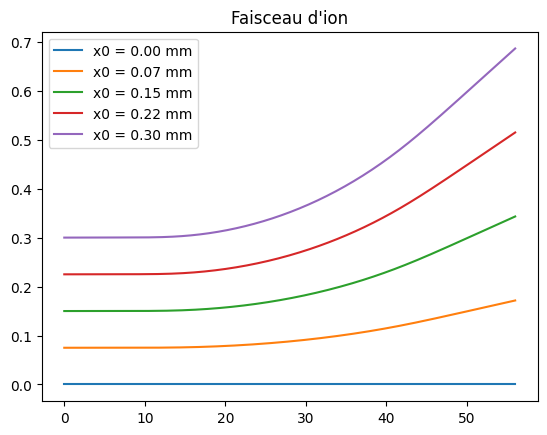

In [ ]:

#faisceau
liste = []

#n nombre d'ion que l'on veut 
nb = 5

positions_initiales = np.linspace(0, 0.3, nb)
for i in positions_initiales:
    ion= Ion(1.6e-27, e, f"Ion_{i:.1f}", i, 0.00, i, 0.00)
    liste.append(ion)


Trajectoire.run_faisceau(liste)

In [ ]:
%reload_ext autoreload 
%autoreload 2

In [ ]:


abberation = Aberration()
c = abberation.coefficient(marginal, Decomp)
print("coefficient d'abberation",c)

300
342


ValueError: when 1d, distances must match the length of the corresponding dimension

Tout le systeme d'okayama

In [ ]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
#quad en entiers
Va = 2000 

tension_quad1 = {
    "va1":  0,   # Tension Aperture 1
    "va2": 0,    # Tension Aperture 2
    "vq13": 0.030872 * Va,    # Tension Quad 1&3
    "vq24": -0.030872* Va,      #tension quad 2 et 4        
    "vaAc": Va,               # Tension acceleation
}

#8 mm
tension_quad2= {
    "va1": - 0.188084 * Va,   # Tension Aperture 1
    "va2": 0.109177 * Va,    # Tension Aperture 2
    "vq13": -0.029909 * Va,    # Tension Quad 1&3
    "vq24": 0.029909 * Va,      #tension quad 2 et 4        
    "vaAc": Va,               # Tension acceleation
}
#21 mm
tension_quad3= {
    "va1":  0.109177 * Va,   # Tension Aperture 1
    "va2": -0.188084 * Va,    # Tension Aperture 2
    "vq13": 0.029909 * Va,    # Tension Quad 1&3
    "vq24": -0.029909 * Va,      #tension quad 2 et 4        
    "vaAc": Va,               # Tension acceleation
}

#8mm
tension_quad4= {
    "va1":  0,   # Tension Aperture 1
    "va2": 0,# Tension Aperture 2
    "vq13": -0.030872 * Va,    # Tension Quad 1&3
    "vq24": 0.030872 * Va,      #tension quad 2 et 4        
    "vaAc": Va,               # Tension acceleation
}

Liste_tension =[tension_quad1, tension_quad2, tension_quad3, tension_quad4]
#Liste_z = [0, 34,82, 113]

Liste_z = [0, 36.8, 80.2, 117]
#Liste_z = [0,37,90.5,127.5]
out_dir = "Files1982"


In [ ]:
okayama = Okayama_quad(out_dir, Liste_z, Liste_tension)
Okayama_path = okayama.save("okayama_quad.npz")

 Fichier sauvegardé pour Extracted_data : Files1982\okayama_quad.npz


In [ ]:
extracted_data2 = Extracted_data(Okayama_path,Liste_z ) 
extracted_data2.derivative()
extracted_data2.position_quad()
Decomp2= Decomposition(extracted_data2)
quad_ent = Data_exploitation_whitoutfit(extracted_data2)
Decomp2.composantes()

c:\Users\llamm\OneDrive\Documents\Projet\BEMPP\okayama\projet_multi\projet-multi-code\Quadrupole_model\Multipolar_decomposition.py:38: RuntimeWarning: divide by zero encountered in divide
  self.Phi0_fit = self.Phi0_maj / self.data.Vapert1
c:\Users\llamm\OneDrive\Documents\Projet\BEMPP\okayama\projet_multi\projet-multi-code\Quadrupole_model\Multipolar_decomposition.py:40: RuntimeWarning: divide by zero encountered in divide
  self.Phi4_fit = self.Phi4_maj *((self.data.radius_axis**4)/ self.data.Vapert1)
c:\Users\llamm\OneDrive\Documents\Projet\BEMPP\okayama\projet_multi\projet-multi-code\Quadrupole_model\Multipolar_decomposition.py:54: RuntimeWarning: divide by zero encountered in divide
  self.k2 = self.Phi2_maj*(self.a)**2/self.psi2


[0, 36.8, 80.2, 117]


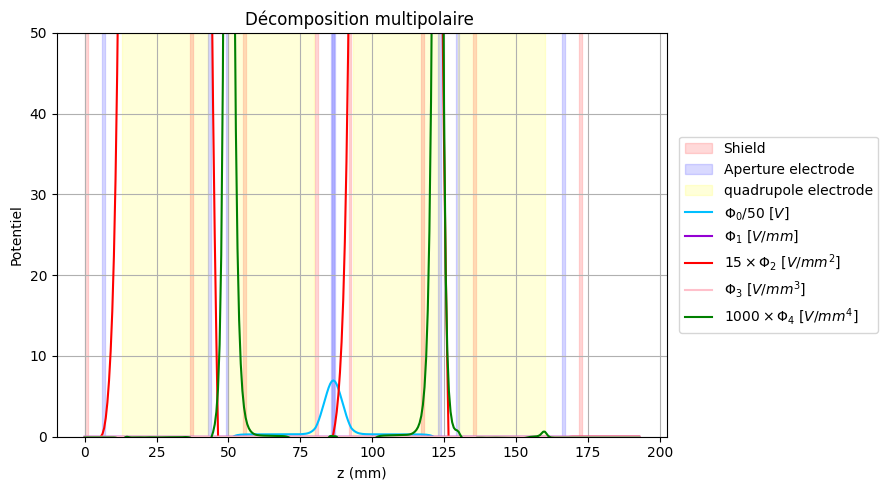

[0, 36.8, 80.2, 117]


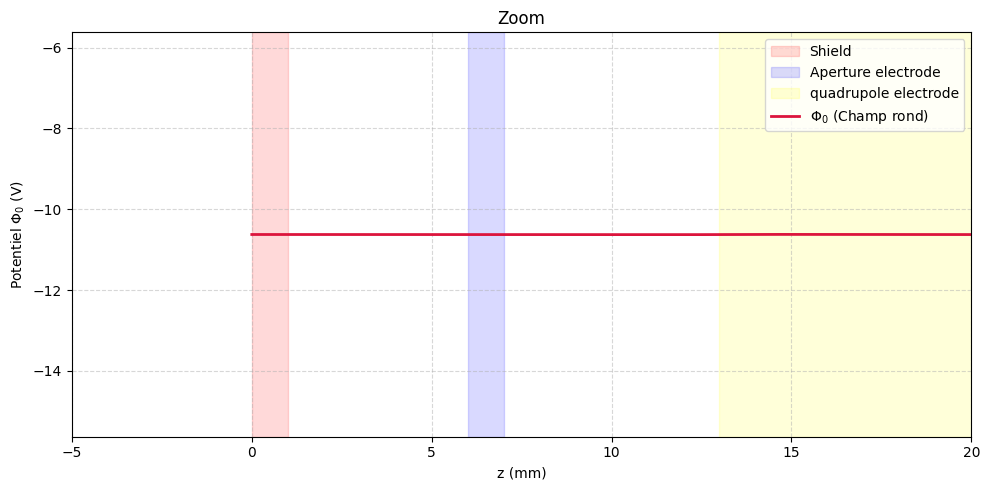

In [ ]:
quad_ent.decomposition_calculation()
quad_ent.decomposition_graph()

2000
2000


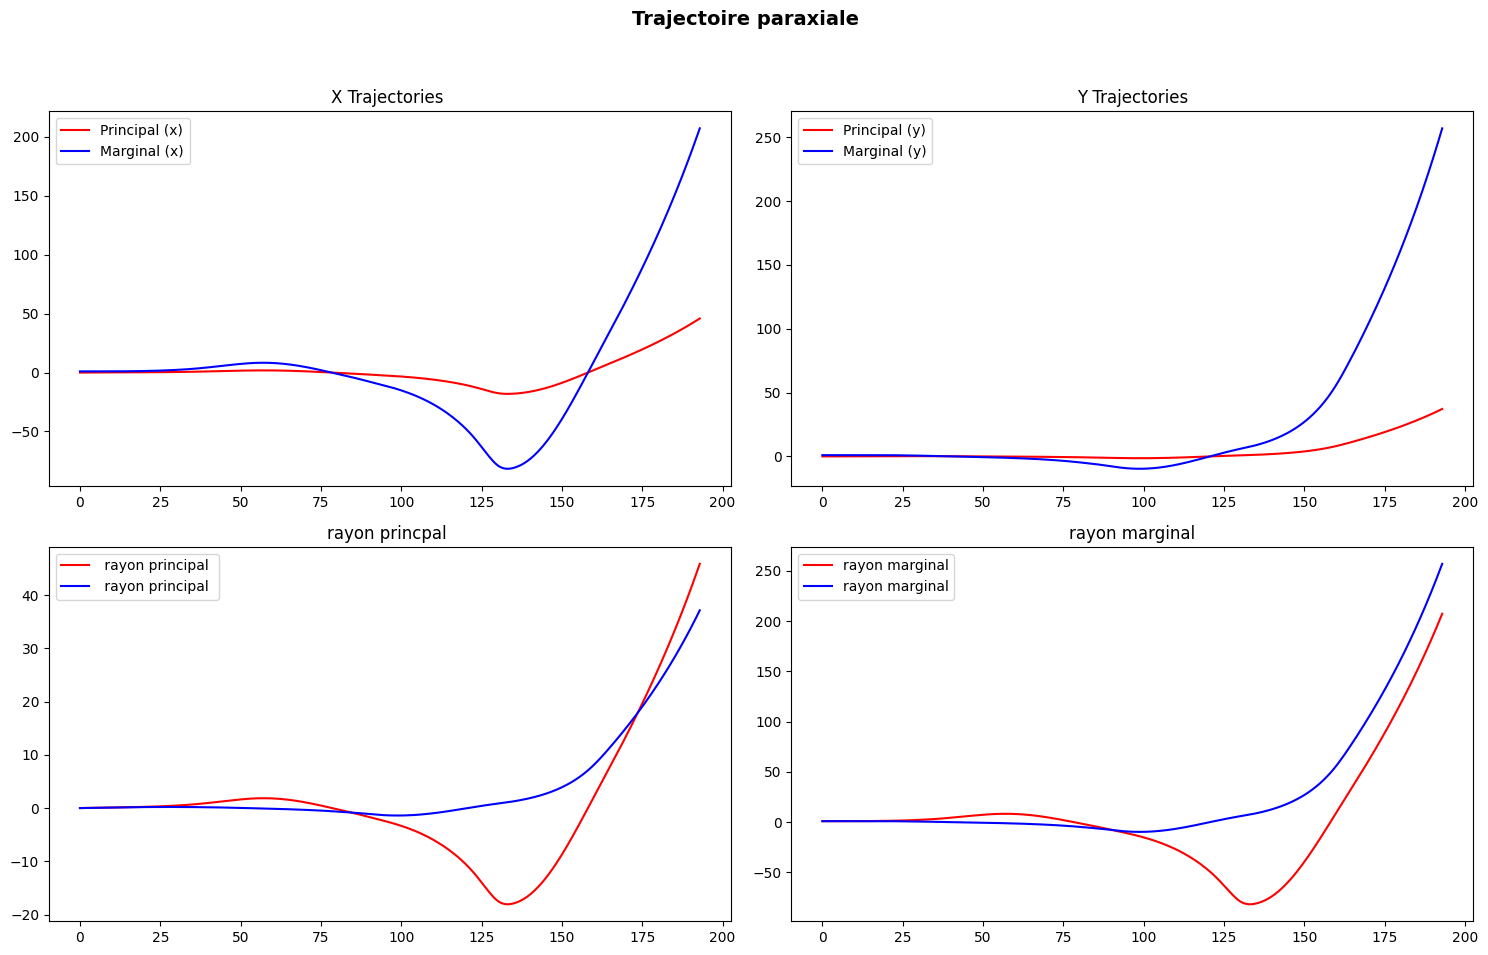

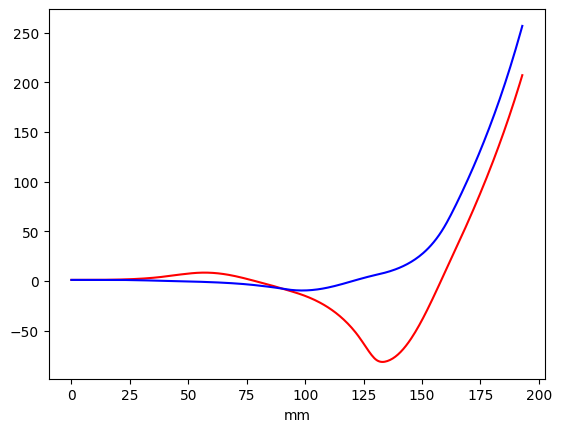

342
342
=== Diagnostic rayon paraxial ===
x[0]  = 0.000000e+00
dx[0] = 9.994689e-03
x[-1] = 3.715762e+01
Mx    = inf
=== Diagnostic potentiels ===
Vacceleration = 2.000000e+03
Phi0_maj max  = 3.485503e+02
k0 max        = 4.653804e+00
phiA min/max  = 3.240258e+01 / 1.999930e+03
R  min/max    = -4.335607e-01 / 1.075687e+01
Q  min/max    = -9.667569e-03 / 9.661470e-03
O  min/max    = -5.307659e-05 / 9.018908e-05
=== Diagnostic termes intégrande ===
Tx4  max = 9.936207e+00
Tx3x max = 2.325029e-01
Tx2x2 max= 7.770692e-02
Txx3 max = 5.568031e-04
Intégrale sans Mx⁴ = 4.218080e+00
C30 final = 2.636300e+07
coefficient d'abberation 26362999.318904433


c:\Users\llamm\OneDrive\Documents\Projet\BEMPP\okayama\projet_multi\projet-multi-code\Quadrupole_model\aberration.py:87: RuntimeWarning: divide by zero encountered in scalar divide
  print(f"Mx    = {x[-1]/x[0]:.6e}")


In [ ]:
n = 100
e = -1.6e-19

marginal = Ion(1.6e-27, e, "principal", 0, 0.01, 0, 0.01)
principal = Ion(1.6e-27, e, "marginal", 1, 0, 1, 0)

marginalc = Ion(1.6e-27, e, "marginal", 0, 0.01, 0, 0.01)
principalc = Ion(1.6e-27, e, "principal", 1, 0, 1, 0)

Trajectoire = SimulationParaxiale(extracted_data2, Decomp2)
Trajectoire.run_discret(marginal, principal)

abberation = Aberration()
c = abberation.coefficient(marginal, Decomp2 )
print("coefficient d'abberation", c)


